(ls_learning)=
```{raw} jupyter
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

# 自指模型中的最小二乘学习

```{contents} Contents
:depth: 2
```

## 概述

本讲座是 {doc}`rational_learning_re` 的配套内容，后者介绍了理性学习的 Bray-Kreps 视角。

我们研究一个相关但不同的问题：在自指模型中，*最小二乘* 学习是否收敛到理性预期均衡。

我们介绍 {cite:t}`MarcetSargent1989jet` 的框架，用于研究一类 **自指** 线性随机模型中的 **最小二乘学习**。

自指模型是指经济的 *实际* 运动规律取决于其中主体的 *感知* 运动规律的模型。

在理性预期均衡（REE）中，两者重合：感知运动规律与实际运动规律相同。

但如果主体从远离均衡的地方出发，通过运行最小二乘回归来更新他们的信念，他们会收敛到 REE 吗？

{cite:t}`MarcetSargent1989jet` 利用系统控制工程中一项强大的技术来回答这个问题：{cite:t}`Ljung1977` 的微分方程方法。

关键洞察是，信念演化的随机差分方程在极限情况下可以由一个确定性的常微分方程（ODE）来近似。

几乎必然收敛可以通过该 ODE 的稳定性来研究。

小型 ODE 的局部稳定性与局部收敛密切相关，而全局几乎必然收敛还需要有界性和吸引域条件。

该框架统一并扩展了 {cite:t}`Bray1982` 和 {cite:t}`BraySavin1986` 的早期工作，并自然地与 {cite:t}`BrayKreps1987` 中讨论的两类学习之间的区别相联系：*在* 理性预期均衡 *内* 学习（在正确设定的模型内进行贝叶斯更新）与 *关于* 理性预期均衡的学习（调整一个数据生成过程随信念变化的 OLS 估计器）。



让我们从整个讲座将使用的导入开始。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import linalg as la
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
import matplotlib as mpl  # i18n
FONTPATH = "fonts/SourceHanSerifSC-SemiBold.otf"  # i18n
mpl.font_manager.fontManager.addfont(FONTPATH)  # i18n
mpl.rcParams['font.family'] = ['Source Han Serif SC']  # i18n

在进行任何模拟之前，我们先描述被学习的对象。

## 自指结构

### 感知运动规律与实际运动规律

在每个日期 $t$，主体持有一个由参数矩阵 $\beta_t$ 概括的 **感知运动规律**。

他们相信，他们所关心的变量 $z_{1t}$ 按照如下方式演化

$$
z_{1t} = \beta_t z_{2,t-1} + \eta_t ,
$$ (eq:perceived_lom)

其中 $z_{2t}$ 是主体用于预测 $z_{1,t+1}$ 的变量向量，而 $\eta_t$ 与所有过去的 $z_2$ 正交。

因为主体基于这一信念进行优化（或行动），他们的行动会反馈到经济中。

为了写出完整状态向量 $z_t = (z_{1t}, z_{1t}^c)^\top$ 的实际运动规律，将 $A(\beta_t)$ 与 $(z_{2,t-1}^c, z_{2,t-1})$ 一致地分块为 $A(\beta_t) = [A_c(\beta_t)\; A_2(\beta_t)]$。

$$
z_t = \begin{bmatrix}
        0 & T(\beta_t) \\
        A_c(\beta_t) & A_2(\beta_t)
      \end{bmatrix}
      \begin{bmatrix} z_{2,t-1}^c \\ z_{2,t-1} \end{bmatrix}
    + \begin{bmatrix} V(\beta_t) \\ B(\beta_t) \end{bmatrix} u_t ,
$$ (eq:actual_lom)

其中 $u_t$ 是协方差为 $\Sigma$ 的 IID 白噪声。

映射 $T$ 是关键对象，因为它将 *感知* 系数 $\beta$ 映射到均衡中 *实际* 支配 $z_{1t}$ 的系数。

**理性预期均衡** 是一个不动点 $\beta_f = T(\beta_f)$。

### 学习机制

主体每期使用 **递归最小二乘**（RLS）来更新 $\beta_t$。

将 $R_t$ 定义为二阶矩矩阵 $E z_{2t}z_{2t}^\top$ 的动态估计。

更新方程为

$$
\beta_t^\top
=
\beta_{t-1}^\top
+ \frac{\alpha_t}{t} R_{t-1}^{-1}
\left\{
z_{2,t-2} z_{2,t-2}^\top
\bigl[ T(\beta_{t-1}) - \beta_{t-1} \bigr]^\top
+ z_{2,t-2} u_{t-1}^\top V(\beta_{t-1})^\top
\right\},
$$ (eq:rls_beta)

$$
R_t = R_{t-1} + \frac{\alpha_t}{t} \bigl[ z_{2,t-1} z_{2,t-1}^\top - R_{t-1}/\alpha_t \bigr] ,
$$ (eq:rls_R)

其中 $\{\alpha_t\}$ 是一个正的、非递减的序列，且当 $t \to \infty$ 时 $\alpha_t \to 1$。

当对所有 $t$ 都有 $\alpha_t = 1$ 时，方程 {eq}`eq:rls_beta`-{eq}`eq:rls_R` 简化为递归更新的 **普通最小二乘法**。

### 滞后数据与同期数据

上述递归是用 *滞后信息* 写出的，因此估计 $\beta_t$ 使用的是直到日期 $t-1$ 为止可用的观测值。

{cite:t}`MarcetSargent1989jet` 也处理了一个 *同期数据* 版本，其中主体在日期 $t$ 使用 $z_{1t}$ 和 $z_{2,t-1}$ 进行更新。

这种时间安排会产生同时决定性，因为 $z_t$ 取决于正在从 $z_t$ 更新出来的同一个估计 $\beta_t$。

一个额外要求是，日期为 $t$ 的系统对每一个历史都必须有唯一解 $(\beta_t, R_t, z_t)$。

如果这个唯一性条件成立，并且下面使用的正则性和有界性条件也成立，那么收敛仍然由同一个完整 ODE {eq}`eq:full_ode` 和小型 ODE {eq}`eq:small_ode` 支配。

```{note}
正如 {cite:t}`BraySavin1986` 和 {cite:t}`BrayKreps1987` 所强调的，RLS 算法不能从应用于正确设定模型的贝叶斯法则推导出来，因为在学习过渡期间，数据生成过程是非平稳的——信念改变了均衡，而均衡又改变了数据。

从它表现得好像环境是平稳的（而实际并非如此）这一意义上说，该算法是 *"非理性的"*。
```

因此，任何对实际运动规律重要的状态变量都必须出现在感知运动规律的回归变量之中。

## 为什么一个微分方程支配极限

RLS 递归 {eq}`eq:rls_beta`-{eq}`eq:rls_R` 是一个 *随机差分方程*，具有两个关键特征。

首先，每次更新前面的 *步长* 是 $\alpha_t / t$，当 $t$ 增长时它收缩到零。

其次，{eq}`eq:rls_beta` 右侧括号内的表达式，在回归变量和噪声的长期平均值处，恰好是差异 $T(\beta_{t-1}) - \beta_{t-1}$，它衡量了感知信念与它们实际生成的运动规律之间的距离。

将这两个事实结合起来，就出现了一幅清晰的图景。

递归每期只对 $\beta_t$ 做微小调整，而这些调整根据大数定律平均后得到确定性漂移 $T(\beta) - \beta$。

随着增益 $\alpha_t/t$ 消失，经过时间重标度的轨迹 $\beta_t$ 越来越像连续时间微分方程的解

$$
\frac{d\beta}{dt} = T(\beta) - \beta .
$$ (eq:small_ode)

为了将 ODE 与经过 $t$ 次观测后的 RLS 进行比较，在 $\tau_t = \sum_{s=1}^t \alpha_s/s$ 处评估 ODE，$\tau_t$ 是学习算法累积的总步长。

当 $\alpha_t=1$ 时，这个累积步长为 $\tau_t = \sum_{s=1}^t 1/s \approx \log t$。

这一想法归功于 {cite:t}`Ljung1977`，它使得 {cite:t}`MarcetSargent1989jet` 能够将对一个含噪声的自适应学习规则的分析简化为对一个确定性 ODE 的更容易的研究。

本节的其余部分将使这一联系变得精确。

## 支配性 ODE

### 小型 ODE 与完整 ODE

*小型 ODE* {eq}`eq:small_ode` 只保留 $\beta$ 中的漂移，将方差估计器 $R$ 保持在其长期值。

它的静止点恰好是模型的理性预期均衡：$\dot\beta = 0$ 当且仅当 $T(\beta) = \beta$。

*完整 ODE* 同时追踪 $\beta$ 和 $R$：

$$
\frac{d}{dt}\begin{bmatrix} \beta^\top \\ R \end{bmatrix}
= \begin{bmatrix} R^{-1} M_{z_2}(\beta)\,[T(\beta) - \beta]^\top \\ M_{z_2}(\beta) - R \end{bmatrix} ,
$$ (eq:full_ode)

其中 $M_{z_2}(\beta) = \mathbb{E}[z_{2t}z_{2t}^\top]$ 是在当主体相信感知规律具有常数参数 $\beta$ 时 $z_{2t}$ 的平稳分布下计算的。

{eq}`eq:full_ode` 的不动点是 $(\beta_f, R_f)$，其中 $R_f = M_{z_2}(\beta_f)$——与小型 ODE 相同的 $\beta_f$，配上与之一致的二阶矩矩阵。

### 正则性假设

{cite:t}`MarcetSargent1989jet` 区分了两组假设，它们的作用相当不同。

前五个是关于算子 $T$、冲击 $u_t$ 和增益序列的标准正则性条件；在应用中它们通常容易检验。

设 $D_s \subset \mathbb{R}^{n_1 \times n_2}$ 为使得 $T(\beta)$、$A(\beta)$、$B(\beta)$、$V(\beta)$ 有良好定义且

$$
\begin{bmatrix}
0 & T(\beta) \\
A_c(\beta) & A_2(\beta)
\end{bmatrix}
$$

的特征值模小于一的集合，从而由信念 $\beta$ 诱导的状态过程是协方差平稳的。

```{prf:assumption} 唯一 REE
:label: ass-ms-a1

算子 $T$ 有唯一不动点 $\beta_f = T(\beta_f)$，且 $\beta_f \in D_s$。
```

```{prf:assumption} T、A、B、V 的光滑性
:label: ass-ms-a2

$T$ 是二次可微的，且 $A, B, V$ 在 $D_s$ 上各有一阶导数。
```

```{prf:assumption} 非奇异极限协方差
:label: ass-ms-a3

协方差矩阵 $M_{z_2}(\beta_f)$ 是非奇异的。
```

```{prf:assumption} 增益序列
:label: ass-ms-a4

对所有 $t$，$\alpha_t > 0$；$\alpha_t$ 关于 $t$ 非递减；当 $t \to \infty$ 时 $\alpha_t \to 1$；且 $\limsup_{t \to \infty} t\,|\alpha_t - \alpha_{t-1}| < \infty$。
```

```{prf:assumption} 冲击矩
:label: ass-ms-a5

向量 $u_t$ 序列独立，且对所有 $p > 1$ 和所有 $i = 1, \ldots, m$ 有 $E|u_{it}|^p < \infty$。
```

这五个假设说的是：存在唯一目标，模型在其周围光滑，回归在极限中有良好定义的精度矩阵，增益以正确的速度收缩，且冲击有足够的矩使大数定律起作用。

其余两个是 *有界性* 条件。

它们是必需的，因为 Ljung 定理要求相关的样本路径无穷多次返回一个有界区域。

在这个模型中，这包括回归变量过程 $z_{2t}$ 和协方差估计 $R_t$。

```{prf:assumption} 沿子序列的有界性
:label: ass-ms-a6

存在一个集合 $\Omega_0$ 满足 $\mathbb{P}(\Omega_0) = 1$，随机变量 $C_1(\omega)$ 和 $C_2(\omega)$，以及一个子序列 $\{t_k(\omega)\}$，使得

$$
|z_{2t_k}(\omega)| < C_1(\omega) \quad\text{and}\quad |R_{t_k}(\omega)| < C_2(\omega)
$$

对所有 $\omega \in \Omega_0$ 和所有 $k = 1, 2, \ldots$ 成立。
```

```{prf:assumption} 样本路径停留在可行域内
:label: ass-ms-a7

紧状态版本或投影集版本之一成立。

- *紧状态版本。*
  - $D_1 = D_2 = \mathbb{R}^{n_1 \times (n_2)^3}$。
  - 存在一个紧集 $D' \subset D_s$，它对所有 $k$ 和所有 $\omega \in \Omega_0$ 都包含 $\beta_{t_k}(\omega)$。
  - 对于每个初始条件 $(\beta(0), R(0))$，其中 $\beta(0) \in D'$ 且 $R(0)$ 如 {prf:ref}`ass-ms-a6` 中所述有界，{eq}`eq:full_ode` 轨迹的 $\beta$ 分量保持在 $D_s$ 的一个闭子集内。

- *投影集版本。*
  - $D_2$ 是闭的。
  - $D_1$ 是开且有界的。
  - 对每个 $(\beta, R) \in D_1$ 都有 $\beta \in D_s$。
  - 初始条件在 $D_2$ 中的 {eq}`eq:full_ode` 轨迹从不离开 $D_1$ 的一个闭子集。
```

当回归变量 $z_{2t}$ 是 *外生的* 且遍历时，{prf:ref}`ass-ms-a6` 是自动成立的，但当 $z_{2t}$ 包含内生变量时，它可能会很微妙。

当模型有一个自然的有界域使 $T$ 有良好定义时，{prf:ref}`ass-ms-a7` 在紧状态版本中得到满足；否则投影集版本对应于使用下面描述的投影机制。

设 $D_A$ 表示 {eq}`eq:full_ode` 的唯一均衡 $(\beta_f, R_f)$ 的吸引域。

### 最小二乘的收敛性

```{prf:proposition} 最小二乘收敛性
:label: prop-ms-convergence

假设 {prf:ref}`ass-ms-a1`、{prf:ref}`ass-ms-a2`、
{prf:ref}`ass-ms-a3`、{prf:ref}`ass-ms-a4`、{prf:ref}`ass-ms-a5`
以及 {prf:ref}`ass-ms-a6` 成立。

如果满足以下之一

- {prf:ref}`ass-ms-a7` 的紧状态版本满足且 $D' \subset D_A$，或
- {prf:ref}`ass-ms-a7` 的投影集版本满足且 $D_1 \subset D_A$，

那么当 $t \to \infty$ 时 $\beta_t \to \beta_f$ 几乎必然成立。
```

{prf:ref}`prop-ms-convergence` 将递归最小二乘的几乎必然收敛问题简化为检验 ODE {eq}`eq:full_ode` 在 $(\beta_f, R_f)$ 处的 *稳定性* 并保证样本路径的有界性。

### 稳定性支配收敛

设 $\mathcal{M}$ 为在 REE $\beta_f$ 处评估的 $T(\beta) - \beta$ 的雅可比矩阵：

$$
\mathcal{M} = \frac{d\,\operatorname{col}(T(\beta) - \beta)}{d\,\operatorname{col}(\beta)^\top}\Bigg|_{\beta=\beta_f} ,
$$ (eq:jacobian)

并设 $h(\beta, R)$ 表示将 $(\beta^\top, R)$ 堆叠成列向量后完整 ODE {eq}`eq:full_ode` 右侧的雅可比矩阵。

```{prf:proposition} 雅可比约化
:label: prop-ms-jacobian-eigenvalues

矩阵 $h(\beta_f, R_f)$ 有 $(n_2)^2$ 个等于 $-1$ 的重复特征值；其余 $n_1 \times n_2$ 个特征值与 $\mathcal{M}$ 的特征值重合。
```

因此：

* 如果 $\mathcal{M}$ 的所有特征值都有 *严格负实部*，那么 {eq}`eq:small_ode` 和 {eq}`eq:full_ode` 都是局部稳定的。

* 在 {prf:ref}`prop-ms-convergence` 的有界性和吸引域条件下，可以利用这种局部稳定性来获得 $\beta_t$ 几乎必然收敛到 $\beta_f$。

* 如果 $\mathcal{M}$ 的任何特征值有 *正实部*，那么下一个命题表明收敛是不可能的。

```{prf:proposition} 必要性
:label: prop-ms-necessity

假设 {prf:ref}`ass-ms-a1`、{prf:ref}`ass-ms-a2`、
{prf:ref}`ass-ms-a3`、{prf:ref}`ass-ms-a4` 和 {prf:ref}`ass-ms-a5` 成立。

1. 设 $\hat\beta \neq \beta_f$ 并假设 $M_{z_2}(\hat\beta)$ 是正定的且 $\hat\beta \in \mathrm{int}(D_2)$。

   那么 $\mathbb{P}(\beta_t \to \hat\beta) = 0$。

2. 如果 $h(\beta_f, R_f)$ 至少有一个特征值具有严格正实部，那么 $\mathbb{P}(\beta_t \to \beta_f) = 0$。
```

第一部分说的是，递归最小二乘不能在可行域内部落到一个非均衡信念上。

如果学习有极限，那么该极限必须是 $T$ 的不动点。

第二部分说的是，局部不稳定性不仅仅是收敛慢的问题。

如果 REE 对于学习 ODE 是不稳定的，那么收敛到该 REE 的概率为零。

稳定性条件对所有 $i$ 都有 $\mathrm{Re}(\lambda_i(\mathcal{M})) < 0$，这被称为 **E-稳定性**（参见 {cite:t}`Evans1985`）：REE 是期望动态 $\dot\beta = T(\beta) - \beta$ 的稳定静止点。

E-稳定性在这里所起的作用类似于贝叶斯学习中先验支持所起的作用：它告诉我们学习过程何时能够找到通往均衡的道路。

### 投影机制

E-稳定性是使 REE 对学习 ODE 有吸引力的局部条件。

单独来看，它并不是一个几乎必然收敛定理。

随机递归还必须停留在 ODE 近似有效的有界区域内。

反过来，一个严格正的特征值排除了收敛到 REE 的可能性，而实部为零的边界情形不在该定理的覆盖范围之内。

Ljung 定理要求学习过程和相关回归变量以概率一返回有界区域。

**投影机制** 是一个强制估计系数和协方差矩阵有界的程序。

#### 投影机制做什么

完整的学习算法用 $(\beta, R)$ 空间中的一个约束集 $D_1 \supset D_2$ 来增强普通的 RLS 更新。

在每一步无约束的 RLS 步骤产生候选 $(\tilde\beta_t, \tilde R_t)$ 之后，投影机制强制执行：

$$
(\beta_t, R_t) = \begin{cases}
  (\tilde\beta_t,\, \tilde R_t) & \text{if } (\tilde\beta_t, \tilde R_t) \in D_1 , \\
  \text{some point in } D_2     & \text{otherwise.}
\end{cases}
$$ (eq:projection)

选择集合 $D_1$ 使模型保持良好定义（例如，$R_t$ 保持正定；$\beta_t$ 停留在一个使 $T(\beta)$ 有良好定义且状态过程协方差平稳的区域内）。

集合 $D_2 \subset D_1$ 是一个稍小的"安全"区域，每当算法有离开 $D_1$ 的危险时，就将其收缩到该区域。

没有投影机制，随机路径 $(\beta_t, R_t)$ 可能会暂时游荡到系统 {eq}`eq:actual_lom` 非平稳的区域（例如，一个爆炸性的 VAR）。

投影机制使 $(\beta_t, R_t)$ 保持在一个选定的可行区域内。

当回归变量包含内生变量时，单独的有界性条件 {prf:ref}`ass-ms-a6` 仍必须沿一个子序列控制 $z_{2t}$。

形式上，{cite:t}`MarcetSargent1989jet` 要求源于 $D_1$ 的完整 ODE {eq}`eq:full_ode` 的轨迹不离开 $D_1$。

这通常通过验证在边界 $\partial D_1$ 处完整向量场指向内部来检验。

```{prf:corollary}
:label: cor-ms-projection-dichotomy

假设 {prf:ref}`ass-ms-a1`、{prf:ref}`ass-ms-a2`、
{prf:ref}`ass-ms-a3`、{prf:ref}`ass-ms-a4`、{prf:ref}`ass-ms-a5`
以及 {prf:ref}`ass-ms-a6` 成立。

进一步假设 $(\beta, R) \in D_1$ 蕴含 $\beta \in D_s$，且 $D_1$ 是开且有界的，满足 $D_1 \subset D_A$。

那么对某个子序列 $\{t_k(\omega)\}$，

$$
\mathbb{P}(\beta_t \to \beta_f) + \mathbb{P}\bigl(\beta_{t_k} \to (D_1 \setminus D_2)\bigr) = 1.
$$
```

每当 ODE 轨迹在 $\partial D_1$ 处指向内部时，第二个事件的概率为零，在这种情况下 {prf:ref}`cor-ms-projection-dichotomy` 简化为 $\beta_t \to \beta_f$ 几乎必然成立。

#### 外生回归变量的情形

当回归变量 $z_{2t}$ 是 *外生的*，使得 $E(z_{2t}z_{2t}^\top) = M_{z_2}(\beta) \equiv M$ 不依赖于 $\beta$ 时，边界条件的验证就变得常规化。

设 $H(\beta)$ 为 $T$ 的中值斜率，即满足

$$
\operatorname{col}\{T(\beta)-T(\beta_f)\}
=
H(\beta)\operatorname{col}(\beta-\beta_f).
$$ (eq:corollary2_cond)

的矩阵。

```{prf:corollary}
:label: cor-ms-exogenous

考虑由 {eq}`eq:rls_beta`-{eq}`eq:rls_R` 以及投影规则 {eq}`eq:projection` 定义的算法。

选择 $0 < K' < K < \infty$ 并假设

1. {prf:ref}`ass-ms-a1`、{prf:ref}`ass-ms-a2`、{prf:ref}`ass-ms-a3`、
   {prf:ref}`ass-ms-a4` 和 {prf:ref}`ass-ms-a5` 成立；
2. $z_{2t}$ 是外生的，使得 $E(z_{2t}z_{2t}^\top) = M_{z_2}(\beta) \equiv M$；
3. 小型 ODE $\dot\beta = T(\beta) - \beta$ 在 $\mathbb{R}^{n_1 \times n_2}$ 中全局稳定；
4. 存在 $\bar\varepsilon > 0$，使得对所有
   $0 < \varepsilon \leq \bar\varepsilon$ 和所有满足
   $|\beta - \beta_f| = K$ 的 $\beta$，
   $[I(1-\varepsilon) + \varepsilon H(\beta)]^\top
   [I(1-\varepsilon) + \varepsilon H(\beta)]$ 的每个特征值的模都小于
   $\alpha^2$，其中 $\alpha < 1$。

取
$D_1 = \{(\beta, R) : |\beta - \beta_f| < K\}$ 和
$D_2 = \{(\beta, R) : |\beta - \beta_f| \leq K'\}$，并让投影规则将 $\beta_t$ 收缩到任何满足 $|\beta - \beta_f| \leq K'$ 的值，同时保持 $R_t = \tilde R_t$。

那么 $\beta_t \to \beta_f$ 几乎必然成立。
```

对于下面的标量线性例子，条件（4）简化为检验 $T$ 的反馈斜率不太强。

对于下面前四个例子，$T$ 是线性的且 $M_{z_2}$ 不依赖于 $\beta$，所以 {prf:ref}`cor-ms-exogenous` 仅使用 $D_1$ 和 $D_2$ 来证明投影论证，并让这些例子进行标量 ODE 稳定性检验。

因此在下面的例子中 $D_1$ 和 $D_2$ 并不是经济学的原始量。

它们是投影学习算法的证明工具：$D_1$ 是模型和 ODE 保持良好定义的外部可行区域，而 $D_2$ 是当更新试图离开 $D_1$ 时用来重置估计的较小区域。

一旦推论说明可以选择合适的集合，这些例子就不再需要展示它们，而可以专注于 $T$、$\beta_f$ 和局部稳定性斜率。

## 五个例子

我们现在逐一研究 {cite:t}`MarcetSargent1989jet` 中的五个例子。

每个实质性的学习例子都遵循相同的模板。

1. 写下决定均衡的经济方程。
2. 代入任何期望变量的感知运动规律，得到作为 $\beta$ 函数的实际运动规律。
3. 读出算子 $T$ 和 REE $\beta_f = T(\beta_f)$。
4. 通过在 $\beta_f$ 处计算 $\mathcal M = dT/d\beta - I$ 来检验 E-稳定性。
5. 绘制 RLS 路径、在累积增益时间处评估的小型 ODE，以及漂移 $T(\beta)-\beta$。

在每种情形中，$\beta_t$ 是主体当前在做决策时使用的运动规律，而 $T(\beta_t)$ 是他们的决策实际产生的运动规律。

最小二乘学习追问的是，重复的观测是否会使 $\beta_t$ 朝着这个映射的不动点移动。

第一个例子是没有自指反馈的对照情形。

对于其余的标量例子，模拟图紧接在模型描述之后出现。

## 例 1：普通线性随机差分方程

第一个例子没有自指成分。

设实际运动规律是固定的，对于一个稳定矩阵 $\Gamma$ 有 $T(\beta)=\Gamma$，且 $V(\beta)=I$。

从经济学上讲，这是对照情形。

主体正在估计一个稳定的、外生的数据生成过程。

他们的信念不会反馈到价格、数量或未来数据中。

REE 是 $\beta_f=\Gamma$。

由于 $T$ 是常数，在 {eq}`eq:corollary2_cond` 中 $H(\beta)=0$。

小型 ODE 的雅可比矩阵是 $\mathcal{M}=-I$，所以小型 ODE 是全局稳定的。

于是 {prf:ref}`cor-ms-exogenous` 蕴含递归最小二乘几乎必然收敛到真实的运动规律。

在这个无反馈基准中，Marcet-Sargent 结果简化为稳定线性随机差分方程的标准最小二乘一致性。

## 例 2：Bray 的蛛网模型

{cite:t}`Bray1982` 研究了一个简单的蛛网经济，其中均衡价格满足

$$
p_t = a + b \beta_t + \tilde{u}_t ,
$$ (eq:bray_price)

其中 $\beta_t$ 是主体对价格的 OLS 估计（他们对 $p_t$ 的点预测），而 $\tilde{u}_t$ 是均值为零、方差为 $\sigma_u^2$ 的 IID 噪声。

这里预测本身是经济的一个状态变量。

如果生产者预期一个高价格，他们当前的供给决策会改变市场出清价格。

参数 $b$ 衡量这种期望反馈的强度。

当 $b < 1$ 时，实际价格反应弱于预测误差，因此最小二乘有一个将信念推回不动点的力量。

当 $b > 1$ 时，反馈太强，同样的学习规则会使信念远离 REE。

映射 $T$ 就是 $T(\beta) = a + b\beta$。

REE 是

$$
\beta_f = \frac{a}{1 - b} , \quad b \neq 1 .
$$ (eq:bray_ree)

小型 ODE 是

$$
\dot\beta = T(\beta) - \beta = a + b\beta - \beta = a - (1-b)\beta ,
$$ (eq:bray_ode)

它有唯一不动点 $\beta_f = a/(1-b)$。

其雅可比矩阵是 $\mathcal{M} = b - 1 < 0$，当 $b < 1$ 时成立。

在上述有界性和域条件下，RLS 于是几乎必然收敛。

当 $b > 1$ 时，$\mathcal{M} > 0$ 且收敛失败。

下面的代码设置 $a=1$ 和 $b=0.6$。

于是理性预期价格预测为 $\beta_f=2.5$。

三个面板显示了含噪声的 RLS 路径、小型 ODE 近似，以及学习漂移 $T(\beta)-\beta$。

下一个单元格设置 Bray 图中使用的模拟器和绘图辅助函数。

In [2]:
def simulate_rls_scalar(T_map, σ_u, β0, T_periods=500, N_paths=100,
                        a_seq=None, seed=0):
    """
    模拟 z1_t = T(β_t) + u_t、z2_t = 1 的 RLS 递归。
    返回一个 (N_paths, T_periods) 的信念路径数组。
    """
    rng = np.random.default_rng(seed)
    if a_seq is None:
        a_seq = np.ones(T_periods)

    β_paths = np.empty((N_paths, T_periods))

    for i in range(N_paths):
        β = β0
        R = 1.0

        for t in range(T_periods):
            α_t = a_seq[t]
            z2 = 1.0
            u_t = rng.normal(0, σ_u)
            z1 = T_map(β) * z2 + u_t

            R_old = max(R, 1e-8)
            β = β + (α_t / (t + 1)) / R_old * z2 * (z1 - β * z2)
            R = R + (α_t / (t + 1)) * (z2**2 - R / α_t)
            R = max(R, 1e-8)

            β_paths[i, t] = β

    return β_paths


def solve_ode_calendar(f_ode, β0, T_periods, a_seq=None):
    """
    求解 dβ/dτ = f_ode(β)，并在 RLS 累积增益时间处评估它。
    """
    if a_seq is None:
        a_seq = np.ones(T_periods)

    periods = np.arange(T_periods + 1)
    gains = a_seq / np.arange(1, T_periods + 1)
    ode_time = np.concatenate(([0.0], np.cumsum(gains)))
    sol = solve_ivp(
        lambda τ, y: [f_ode(y[0])],
        (0.0, ode_time[-1]),
        [β0],
        t_eval=ode_time,
        method='RK45',
        max_step=0.05
    )
    return periods, sol.y[0]


def plot_scalar_drift(ax, β_grid, drift, β_f, color):
    """绘制一维学习漂移 T(β) - β。"""
    ax.plot(β_grid, drift, color=color, lw=2)
    ax.axhline(0, color='black', lw=1.5)
    ax.axvline(β_f, color='red', ls='--', lw=2,
               label=f'$\\beta_f = {β_f:.2f}$')
    ax.fill_between(β_grid, drift, 0, where=(drift > 0),
                    color=color, alpha=0.12)
    ax.fill_between(β_grid, drift, 0, where=(drift < 0),
                    color=color, alpha=0.12)

    for β_arrow in np.linspace(β_grid[20], β_grid[-20], 7):
        dβ = np.interp(β_arrow, β_grid, drift)
        if abs(dβ) > 1e-10:
            ax.annotate(
                '', xy=(β_arrow + 0.25 * np.sign(dβ), 0),
                xytext=(β_arrow, 0),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.8)
            )

    ax.set_xlabel('$\\beta$')
    ax.set_ylabel('$T(\\beta) - \\beta$')
    ax.legend(fontsize=9)


T_sim = 400
N_sim = 80

findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


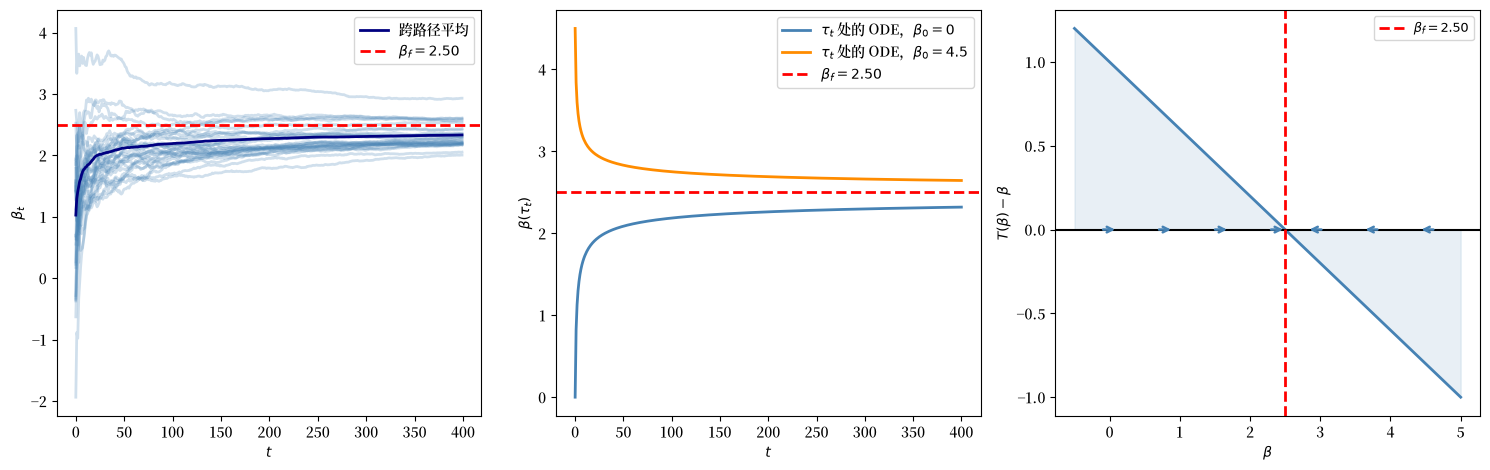

REE: β_f = a/(1-b) = 2.5000
Jacobian M = b - 1 = -0.4000  (< 0: E-stable)


In [3]:
a_bray, b_bray, σ_bray = 1.0, 0.6, 1.0


def T_bray(β):
    return a_bray + b_bray * β


β_f_bray = a_bray / (1 - b_bray)

β0_bray = 0.0

β_paths_bray = simulate_rls_scalar(
    T_bray, σ_bray, β0_bray,
    T_periods=T_sim, N_paths=N_sim
)


def ode_bray(β):
    return a_bray + b_bray * β - β


t_ode, sol_low = solve_ode_calendar(ode_bray, 0.0, T_sim)
_, sol_high = solve_ode_calendar(ode_bray, 4.5, T_sim)

β_grid_bray = np.linspace(-0.5, 5.0, 300)
drift_bray = np.array([ode_bray(b) for b in β_grid_bray])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

ax = axes[0]
for i in range(min(30, N_sim)):
    ax.plot(β_paths_bray[i], color='steelblue', alpha=0.25, lw=2)
ax.plot(np.mean(β_paths_bray, axis=0), color='navy', lw=2,
        label='跨路径平均')
ax.axhline(β_f_bray, color='red', ls='--', lw=2,
           label=f'$\\beta_f = {β_f_bray:.2f}$')
ax.set_xlabel('$t$')
ax.set_ylabel('$\\beta_t$')
ax.legend()

ax = axes[1]
ax.plot(
    t_ode, sol_low, color='steelblue', lw=2,
    label='$\\tau_t$ 处的 ODE，$\\beta_0=0$'
)
ax.plot(
    t_ode, sol_high, color='darkorange', lw=2,
    label='$\\tau_t$ 处的 ODE，$\\beta_0=4.5$'
)
ax.axhline(β_f_bray, color='red', ls='--', lw=2,
           label=f'$\\beta_f = {β_f_bray:.2f}$')
ax.set_xlabel('$t$')
ax.set_ylabel('$\\beta(\\tau_t)$')
ax.legend()

plot_scalar_drift(
    axes[2], β_grid_bray, drift_bray, β_f_bray, 'steelblue'
)

plt.tight_layout()
plt.show()
print(f"REE: β_f = a/(1-b) = {β_f_bray:.4f}")
print(f"Jacobian M = b - 1 = {b_bray - 1:.4f}  (< 0: E-stable)")

随机路径含有噪声，因为价格中含有 $\tilde u_t$。

平均路径和 ODE 路径消除了大部分噪声，揭示了平均学习方向。

## 反例：不稳定的 Bray 反馈

为了看看当 E-稳定性被违反时会发生什么，用 $b > 1$ 重复 Bray 的模型。

它代表一个经济，其中期望对实际价格的影响超过一比一。

如果主体从一个过高的预测出发，那么该预测诱导的市场结果会更高，因此最小二乘会提高预测。

在 REE 以下，同样的逻辑反向起作用。

REE 存在，但它无法被这个自适应规则学到。

现在同样的三个诊断面板显示了信念如何被推离 REE 而不是朝向它，而漂移面板显示学习力量在两侧都指向远离不动点的方向。

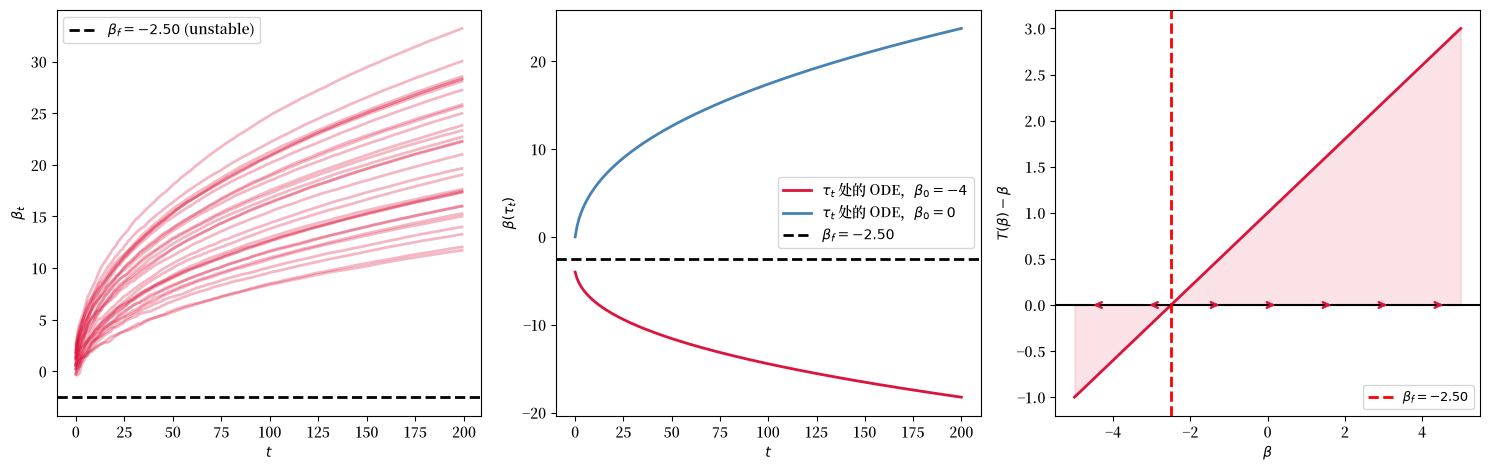

Jacobian M = b - 1 = 0.40  (> 0: NOT E-stable)


In [4]:
b_unstable = 1.4


def T_unstable(β):
    return a_bray + b_unstable * β


β_f_unstable = a_bray / (1 - b_unstable)

β_paths_unstable = simulate_rls_scalar(
    T_unstable, σ_bray, β0=0.0,
    T_periods=200, N_paths=50
)


def ode_unstable(β):
    return T_unstable(β) - β


β_grid = np.linspace(-5, 5, 300)
drift = np.array([ode_unstable(b) for b in β_grid])

t_ode_un, sol_un_low = solve_ode_calendar(ode_unstable, -4.0, 200)
_, sol_un_high = solve_ode_calendar(ode_unstable, 0.0, 200)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

ax = axes[0]
for i in range(min(30, 50)):
    ax.plot(β_paths_unstable[i], color='crimson', alpha=0.3, lw=2)
ax.axhline(β_f_unstable, color='black', ls='--', lw=2,
           label=f'$\\beta_f = {β_f_unstable:.2f}$ (unstable)')
ax.set_xlabel('$t$')
ax.set_ylabel('$\\beta_t$')
ax.legend()

ax = axes[1]
ax.plot(
    t_ode_un, sol_un_low, color='crimson', lw=2,
    label='$\\tau_t$ 处的 ODE，$\\beta_0=-4$'
)
ax.plot(
    t_ode_un, sol_un_high, color='steelblue', lw=2,
    label='$\\tau_t$ 处的 ODE，$\\beta_0=0$'
)
ax.axhline(β_f_unstable, color='black', ls='--', lw=2,
           label=f'$\\beta_f = {β_f_unstable:.2f}$')
ax.set_xlabel('$t$')
ax.set_ylabel('$\\beta(\\tau_t)$')
ax.legend()

plot_scalar_drift(
    axes[2], β_grid, drift, β_f_unstable, 'crimson'
)

plt.tight_layout()
plt.show()
print(f"Jacobian M = b - 1 = {b_unstable - 1:.2f}  (> 0: NOT E-stable)")

## 例 3：Bray-Savin 供给移动因子模型

{cite:t}`BraySavin1986` 研究了一个模型，其中

$$
p_t = x_t^\top(m + a\beta_{t-1}) + \tilde{u}_t , \quad p_t^e = x_t^\top\beta_{t-1} ,
$$ (eq:bs_price)

其中 $x_t$ 是外生供给移动因子，$a$ 是标量反馈参数，主体运行 $p$ 对 $x$ 的 OLS 回归。

这是同样的学习问题，只多了一个额外的经济要素：期望以一个观测到的移动因子为条件。

主体不只是预测平均价格。

他们估计价格如何对 $x_t$ 做出反应。

$x_t$ 上的实际系数是 $m+a\beta$，因此感知斜率改变了市场生成的真实斜率。

如果 $a < 1$，一个错误的斜率以衰减的方式反馈到实际价格方程中，最小二乘估计被拉向 REE 斜率。

映射是 $T(\beta) = m + a\beta$（标量情形），给出

$$
\dot\beta = (a-1)\beta + m , \quad \beta_f = \frac{m}{1-a} ,
$$ (eq:bs_ode)

雅可比矩阵为 $\mathcal{M} = a - 1 < 0$ 当且仅当 $a < 1$。

下面的模拟抽取外生移动因子 $x_t$，并让主体更新 $p_t$ 对 $x_t$ 回归中的斜率。

它使用 $a=0.7$。

漂移面板显示错误的斜率被推回 REE 斜率，而不是被放大。

下一个单元格将 RLS 模拟器调整为供给移动因子回归。

In [5]:
def simulate_bray_savin(m, a, σ_x, σ_u, β0, T_periods=500,
                        N_paths=100, seed=0):
    """
    模拟 p_t = x_t (m + a β_t) + u_t 的 RLS。
    主体将 p_t 对 x_t 回归。
    """
    rng = np.random.default_rng(seed)
    β_paths = np.empty((N_paths, T_periods))

    for i in range(N_paths):
        β = β0
        R = 1.0

        for t in range(T_periods):
            x_t = rng.normal(0.0, σ_x)
            u_t = rng.normal(0.0, σ_u)
            p_t = x_t * (m + a * β) + u_t
            step = 1.0 / (t + 1)

            R_old = max(R, 1e-8)
            β = β + step / R_old * x_t * (p_t - β * x_t)
            R = R + step * (x_t**2 - R)
            R = max(R, 1e-8)
            β_paths[i, t] = β

    return β_paths

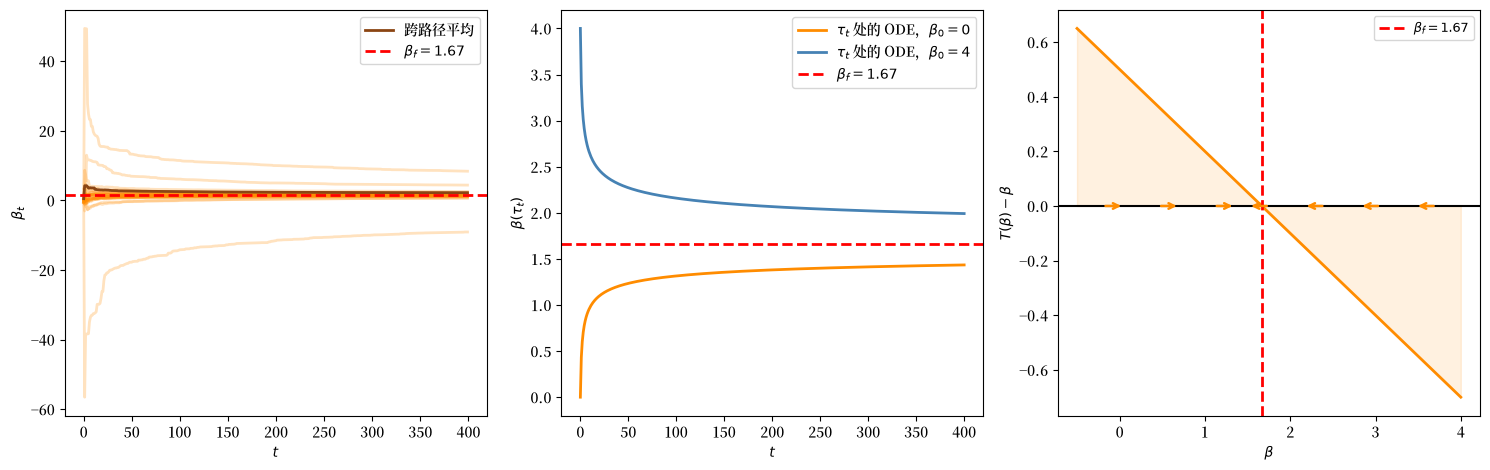

REE: β_f = m/(1-a) = 1.6667
Jacobian M = a - 1 = -0.3000  (< 0: E-stable)


In [6]:
m_bs, a_bs = 0.5, 0.7
σ_x_bs, σ_u_bs = 1.0, 1.0


def T_bs(β):
    return m_bs + a_bs * β


β_f_bs = m_bs / (1 - a_bs)

β_paths_bs = simulate_bray_savin(
    m_bs, a_bs, σ_x_bs, σ_u_bs, 0.0,
    T_periods=T_sim, N_paths=N_sim
)


def ode_bs(β):
    return T_bs(β) - β


t_ode_bs, sol_bs_low = solve_ode_calendar(ode_bs, 0.0, T_sim)
_, sol_bs_high = solve_ode_calendar(ode_bs, 4.0, T_sim)

β_grid_bs = np.linspace(-0.5, 4.0, 300)
drift_bs = np.array([ode_bs(b) for b in β_grid_bs])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

ax = axes[0]
for i in range(min(30, N_sim)):
    ax.plot(β_paths_bs[i], color='darkorange', alpha=0.25, lw=2)
ax.plot(np.mean(β_paths_bs, axis=0), color='saddlebrown', lw=2,
        label='跨路径平均')
ax.axhline(β_f_bs, color='red', ls='--', lw=2,
           label=f'$\\beta_f = {β_f_bs:.2f}$')
ax.set_xlabel('$t$')
ax.set_ylabel('$\\beta_t$')
ax.legend()

ax = axes[1]
ax.plot(
    t_ode_bs, sol_bs_low, color='darkorange', lw=2,
    label='$\\tau_t$ 处的 ODE，$\\beta_0=0$'
)
ax.plot(
    t_ode_bs, sol_bs_high, color='steelblue', lw=2,
    label='$\\tau_t$ 处的 ODE，$\\beta_0=4$'
)
ax.axhline(β_f_bs, color='red', ls='--', lw=2,
           label=f'$\\beta_f = {β_f_bs:.2f}$')
ax.set_xlabel('$t$')
ax.set_ylabel('$\\beta(\\tau_t)$')
ax.legend()

plot_scalar_drift(
    axes[2], β_grid_bs, drift_bs, β_f_bs, 'darkorange'
)

plt.tight_layout()
plt.show()
print(f"REE: β_f = m/(1-a) = {β_f_bs:.4f}")
print(f"Jacobian M = a - 1 = {a_bs - 1:.4f}  (< 0: E-stable)")

其解释与 Bray 的蛛网模型相似。

不同之处在于，主体现在学习的是价格如何与一个外生变量共同变动，而不仅仅是学习一个无条件均值。

## 例 4：恶性通货膨胀/资产价格

考虑现值资产定价模型

$$
y_t = \lambda \mathbb{E}_t y_{t+1} + x_t , \quad x_t = \rho x_{t-1} + \varepsilon_t ,
$$ (eq:pv_model)

其中 $|\lambda| < 1$、$|\rho| < 1$，且主体感知 $y_t = \beta_t x_{t-1}+ v_t$。

在感知规律下，$\mathbb{E}_t y_{t+1} = \beta_t x_t$，所以 {eq}`eq:pv_model` 变为

$$
y_t = (\lambda \beta_t + 1) x_t = (\lambda \beta_t + 1)\rho x_{t-1} + (\lambda \beta_t + 1)\varepsilon_t.
$$

因此实际运动规律中 $x_{t-1}$ 上的系数是 $(\lambda \beta_t + 1)\rho$，它给出了下面的算子 $T$。

如果 $y_t$ 是价格水平，这个方程类似于 Cagan 式的恶性通货膨胀模型。

如果 $y_t$ 是资产价格且 $x_t$ 是股息或基本面，那么它是一个现值关系。

在这两种情形中，关于 $y$ 未来价值的信念都进入了 $y$ 的当前价值。

乘积 $\lambda\rho$ 衡量前瞻性反馈的强度：$\lambda$ 对未来贴现，$\rho$ 衡量基本面的持续性。

当 $|\lambda\rho|<1$ 时，一个错误的感知系数不会无界地放大。

映射是 $T(\beta) = (\lambda\beta + 1)\rho$，REE 是

$$
\beta_f = \frac{\rho}{1 - \lambda\rho} .
$$ (eq:pv_ree)

小型 ODE 是

$$
\dot\beta = (\lambda\rho - 1)\beta + \rho ,
$$ (eq:pv_ode)

对于 $|\lambda\rho| < 1$，雅可比矩阵为 $\mathcal{M} = \lambda\rho - 1 < 0$，所以小型 ODE 是稳定的。

于是收敛定理在上述外生回归变量条件下适用。

模拟使用 $\lambda=0.8$ 和 $\rho=0.9$，所以 $\lambda\rho=0.72$。

这意味着来自期望的反馈足够强到有影响，但仍小于一。

下面的 ODE 面板在水平轴上使用 $\tau$ 本身，其中 $\tau$ 是最小二乘累积的总步长。

代码模拟自回归基本面 $x_t$，并更新 $y_t$ 对 $x_{t-1}$ 的 OLS 回归。

下一个单元格模拟自回归基本面和匹配的 RLS 更新。

它使协方差估计 $R_t$ 保持远离零，模仿上面的投影思想，避免误导性的早期样本爆炸。

In [7]:
def simulate_present_value_rls(λ, ρ, σ_ε, β0, T_periods=500,
                               N_paths=100, seed=0):
    """
    模拟 y_t = (λ β_t + 1) x_t、
    x_t = ρ x_{t-1} + ε_t 的 RLS，将 y_t 对 x_{t-1} 回归。
    """
    rng = np.random.default_rng(seed)
    β_paths = np.empty((N_paths, T_periods))
    σ_x = σ_ε / np.sqrt(1 - ρ**2)
    R_min = 0.05 * σ_x**2

    for i in range(N_paths):
        β = β0
        R = σ_x**2
        x_lag = rng.normal(0.0, σ_x)

        for t in range(T_periods):
            ε_t = rng.normal(0.0, σ_ε)
            x_t = ρ * x_lag + ε_t
            y_t = (λ * β + 1.0) * x_t
            step = 1.0 / (t + 1)

            R_old = max(R, R_min)
            β = β + step / R_old * x_lag * (y_t - β * x_lag)
            R = R + step * (x_lag**2 - R)
            R = max(R, R_min)
            β_paths[i, t] = β
            x_lag = x_t

    return β_paths

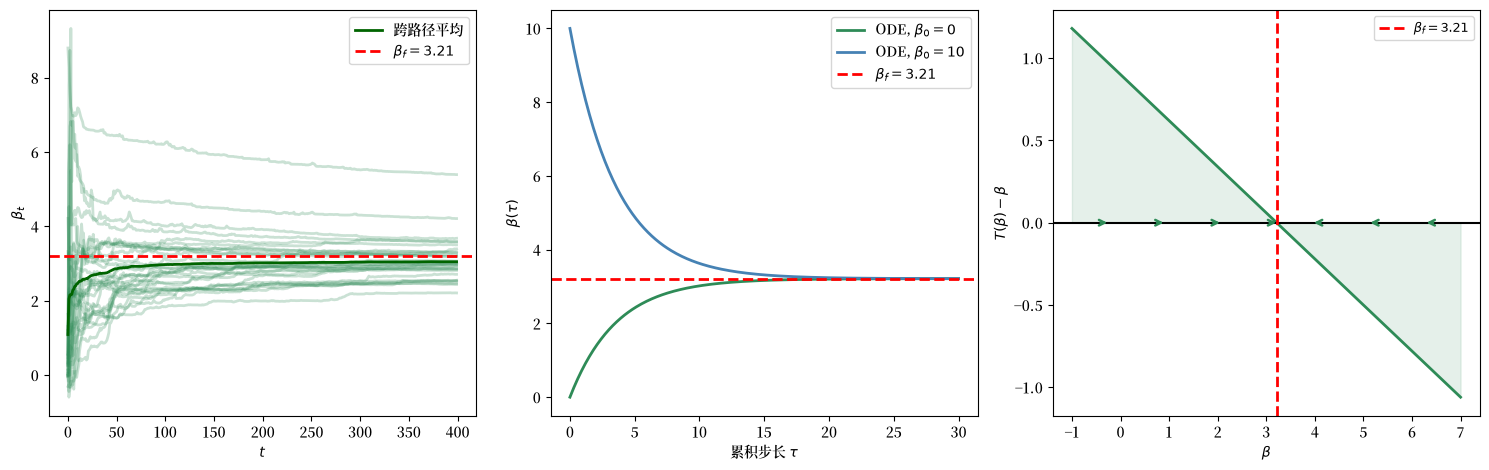

REE: β_f = ρ/(1 - lambda*ρ) = 3.2143
Jacobian M = lambda*ρ - 1 = -0.2800  (< 0: E-stable)


In [8]:
λ, ρ_pv, σ_pv = 0.8, 0.9, 1.0
T_pv_sim = T_sim
N_pv_sim = N_sim


def T_pv(β):
    return (λ * β + 1) * ρ_pv


β_f_pv = ρ_pv / (1 - λ * ρ_pv)

β_paths_pv = simulate_present_value_rls(
    λ, ρ_pv, σ_pv, 0.0,
    T_periods=T_pv_sim, N_paths=N_pv_sim
)


def ode_pv(β):
    return T_pv(β) - β


τ_grid_pv = np.linspace(0.0, 30.0, 300)
sol_pv_low = solve_ivp(
    lambda τ, y: [ode_pv(y[0])],
    (0.0, τ_grid_pv[-1]),
    [0.0],
    t_eval=τ_grid_pv,
    max_step=0.05
).y[0]
sol_pv_high = solve_ivp(
    lambda τ, y: [ode_pv(y[0])],
    (0.0, τ_grid_pv[-1]),
    [10.0],
    t_eval=τ_grid_pv,
    max_step=0.05
).y[0]

β_grid_pv = np.linspace(-1.0, 7.0, 300)
drift_pv = np.array([ode_pv(b) for b in β_grid_pv])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

ax = axes[0]
for i in range(min(30, N_pv_sim)):
    ax.plot(β_paths_pv[i], color='seagreen', alpha=0.25, lw=2)
ax.plot(np.mean(β_paths_pv, axis=0), color='darkgreen', lw=2,
        label='跨路径平均')
ax.axhline(β_f_pv, color='red', ls='--', lw=2,
           label=f'$\\beta_f = {β_f_pv:.2f}$')
ax.set_xlabel('$t$')
ax.set_ylabel('$\\beta_t$')
ax.legend()

ax = axes[1]
ax.plot(
    τ_grid_pv, sol_pv_low, color='seagreen', lw=2,
    label='ODE, $\\beta_0=0$'
)
ax.plot(
    τ_grid_pv, sol_pv_high, color='steelblue', lw=2,
    label='ODE, $\\beta_0=10$'
)
ax.axhline(β_f_pv, color='red', ls='--', lw=2,
           label=f'$\\beta_f = {β_f_pv:.2f}$')
ax.set_xlabel('累积步长 $\\tau$')
ax.set_ylabel('$\\beta(\\tau)$')
ax.legend()

plot_scalar_drift(
    axes[2], β_grid_pv, drift_pv, β_f_pv, 'seagreen'
)

plt.tight_layout()
plt.show()
print(f"REE: β_f = ρ/(1 - lambda*ρ) = {β_f_pv:.4f}")
print(f"Jacobian M = lambda*ρ - 1 = {λ*ρ_pv - 1:.4f}  (< 0: E-stable)")

REE 系数大于 $\rho$，因为当前价格资本化了预期的未来基本面。

学习之所以收敛，是因为 $\beta_t$ 的每次修正都改变了期望，但贴现的持续性项 $\lambda\rho$ 阻止了修正以爆炸性的方式反馈。

## 例 5：不确定性下的投资

现在让我们考虑 Lucas-Prescott 投资模型的一个版本，其中主体通过对 $(K_{t-1}, w_{t-1})$ 回归来学习关于总资本存量 $K_t$ 的信息，其中 $w_t$ 是外生成本冲击。


企业使用总资本的感知运动规律来选择投资。

这些投资选择然后通过市场出清决定了总资本的实际运动规律。

因此学习是关于一个状态变量的，而主体自己通过其投资决策帮助创造了这个状态变量。

感知运动规律是

$$
K_t = \beta_1 K_{t-1} + \beta_2 w_{t-1} + \eta_t ,
$$

而实际规律（来自企业的最优投资决策和市场出清）是

$$
K_t = T_1(\beta) K_{t-1} + T_2(\beta) w_{t-1} + V(\beta) u_t ,
$$ (eq:inv_actual)

其中非线性映射 $T_1, T_2$ 来自求解企业的线性二次控制问题。

这两个系数具有不同的经济作用。

$\beta_1$ 描述总资本中的持续性，而 $\beta_2$ 描述外生冲击 $w_t$ 如何影响下一期的资本。

因为最优投资规则取决于整个感知运动规律，映射 $T$ 是非线性的。

这就是为什么这里较大的 ODE 比外生回归变量的标量例子更难分析。

小型 ODE 分解为：

$$
\dot\beta_1 = T_1(\beta_1) - \beta_1 , \quad
\dot\beta_2 = T_2(\beta_1, \beta_2) - \beta_2 ,
$$ (eq:inv_ode)

E-稳定性可以对 $|\beta_1| < b^{-1/2}$（其中 $b$ 是贴现因子）解析地验证。


下面的相图在 $(\beta_1,\beta_2)$ 空间上绘制了向量场 $T(\beta)-\beta$。

每个箭头显示如果经济当前在该信念下运行，感知运动规律将如何被修正。

所绘制的轨迹是确定性的 ODE 路径，而不是含噪声的最小二乘样本路径。

REE: β_f = [ 0.38728475 -0.28879438]
Jacobian M eigenvalues: [-1.27718071 -1.35664898]
E-stable: True


findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


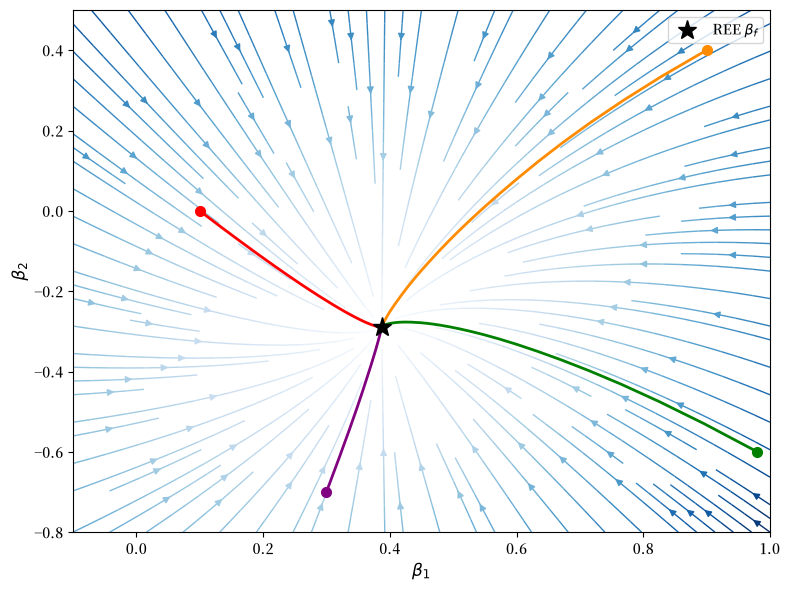

In [9]:
def T_invest(β, b=0.95, d=1.0, f=1.0, A1=1.0, N=1.0, ρ_w=0.5):
    """投资模型的映射 T，其中 β = [β1, β2]。"""
    b1, b2 = β
    denom1 = 1 - b1 * b + (1 / d) * f**2 * A1 * N
    T1 = (1 - b1 * b) / denom1
    numer2 = 1 - b1 * b + f**2 * A1 * b2 * b * ρ_w
    T2 = (-N / (d * (1 - ρ_w * b))) * (numer2 / denom1) * ρ_w
    return np.array([T1, T2])


def ode_invest(t, β, **kwargs):
    Tb = T_invest(β, **kwargs)
    return Tb - β


params = dict(b=0.95, d=1.0, f=1.0, A1=1.0, N=1.0, ρ_w=0.5)
β1_bound = params["b"] ** (-0.5)
β_f_inv = fsolve(lambda b: T_invest(b, **params) - b, [0.5, 0.1])
print(f"REE: β_f = {β_f_inv}")

eps = 1e-6
J = np.zeros((2, 2))
for j in range(2):
    e = np.zeros(2)
    e[j] = eps
    J[:, j] = (
        T_invest(β_f_inv + e, **params)
        - T_invest(β_f_inv - e, **params)
    ) / (2 * eps)
M = J - np.eye(2)
eigs = la.eigvals(M)
print(f"Jacobian M eigenvalues: {eigs}")
print(f"E-stable: {np.all(eigs.real < 0)}")

fig, ax = plt.subplots(figsize=(8, 6))

b1_grid = np.linspace(-0.1, min(1.0, β1_bound - 1e-3), 20)
b2_grid = np.linspace(-0.8, 0.5, 20)
B1, B2 = np.meshgrid(b1_grid, b2_grid)
U = np.zeros_like(B1)
V_field = np.zeros_like(B2)
for i in range(B1.shape[0]):
    for j in range(B1.shape[1]):
        β_ij = np.array([B1[i, j], B2[i, j]])
        drift = T_invest(β_ij, **params) - β_ij
        U[i, j] = drift[0]
        V_field[i, j] = drift[1]

speed = np.sqrt(U**2 + V_field**2)
speed[speed == 0] = 1e-8
ax.streamplot(b1_grid, b2_grid, U, V_field, color=speed,
              cmap='Blues', density=1.3, linewidth=1)

starts = [(0.1, 0.0), (0.9, 0.4), (0.98, -0.6), (0.3, -0.7)]
colors_traj = ['red', 'darkorange', 'green', 'purple']
for (b10, b20), col in zip(starts, colors_traj):
    sol = solve_ivp(lambda t, β: ode_invest(t, β, **params),
                    [0, 30], [b10, b20],
                    t_eval=np.linspace(0, 30, 300),
                    method='RK45')
    ax.plot(sol.y[0], sol.y[1], color=col, lw=2)
    ax.plot(b10, b20, 'o', color=col, ms=7)

ax.plot(*β_f_inv, 'k*', ms=14, label='REE $\\beta_f$')
ax.set_xlabel('$\\beta_1$', fontsize=12)
ax.set_ylabel('$\\beta_2$', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

星号标记 REE。

路径之所以收敛，是因为资本持续性系数 $\beta_1$ 首先被稳定下来，然后给定 $\beta_1$ 的极限值，冲击系数 $\beta_2$ 进行调整。

这种递归结构就是为什么即使完整的最小二乘系统有内生回归变量，小型 ODE 仍然是可处理的。

## 与理性学习的联系

{cite:t}`MarcetSargent1989jet` 的框架属于 *关于* 理性预期均衡的学习纲领，与 *在* 均衡 *内* 学习不同——这一区别由 {cite:t}`BrayKreps1987` 强调。

*在* REE *内* 学习（配套讲座 [](rational_learning_re) 的主题）指的是在正确设定的模型内进行贝叶斯推断。

在那种设定中，从主体的视角来看，数据生成过程是平稳的，贝叶斯法则是完全合理化的。

**关于 REE 的学习** 涉及一个不知道均衡价格函数的主体。

因为主体的信念改变了均衡价格，主体用来更新信念的数据本身是由一个非平稳过程生成的。

正如 {cite:t}`MarcetSargent1989jet` 所说，

> 这些模型没有纳入完全最优的行为或理性预期，因为主体在持续被证伪的假设下运作，即运动规律是时间不变且确定已知的。

然而它是一个令人信服的规则。

每当 E-稳定性与所需的有界性和吸引域条件结合时，尽管存在错误设定，收敛仍然成立。

与贝叶斯学习不同，它不需要关于经济统计结构的强先验假设。


## 总结

本讲座研究了 {cite:t}`MarcetSargent1989jet` 自指模型中的最小二乘学习。

核心对象是从感知运动规律到当主体基于该感知行动时生成的实际运动规律的映射 $T$。

理性预期均衡是这个映射的不动点。

当相关的 ODE $\dot\beta = T(\beta)-\beta$ 局部稳定且学习过程保持在模型有良好定义的区域内时，递归最小二乘收敛到那个不动点。

它补充了在 {doc}`rational_learning_re` 中研究的理性学习，在那里贝叶斯主体在一个已经设定好的均衡结构 *内* 进行学习。

## 练习

```{exercise}
:label: ls_ex1

考虑标量模型，其中 $T(\beta) = a + b\beta$。

1. 推导唯一 REE $\beta_f$ 关于 $a$ 和 $b$ 的公式。

2. 证明小型 ODE $\dot\beta = T(\beta) - \beta$ 全局稳定当且仅当 $b < 1$。

3. 对于 $a = 1$ 和 $b \in \{0.3, 0.7, 0.9, 0.99\}$ 中的每一个（都小于 1），模拟 $N = 200$ 条长度为 $T = 500$ 的路径。

在同一张图上为每个 $b$ 值绘制 $\beta_t$ 的跨路径平均，并评论当 $b \to 1$ 时收敛速度如何变化。
```

```{solution-start} ls_ex1
:class: dropdown
```

这是一个解答：

*第 1 部分。* REE 满足 $\beta_f = T(\beta_f) = a + b\beta_f$，所以

$$
\beta_f (1 - b) = a \implies \beta_f = \frac{a}{1-b} .
$$

*第 2 部分。* 小型 ODE 是 $\dot\beta = a + b\beta - \beta = a - (1-b)\beta$。

这是线性的，斜率为 $-(1-b)$，所以唯一不动点 $\beta_f = a/(1-b)$ 全局稳定当且仅当 $1-b > 0$，即 $b < 1$。

*第 3 部分。*

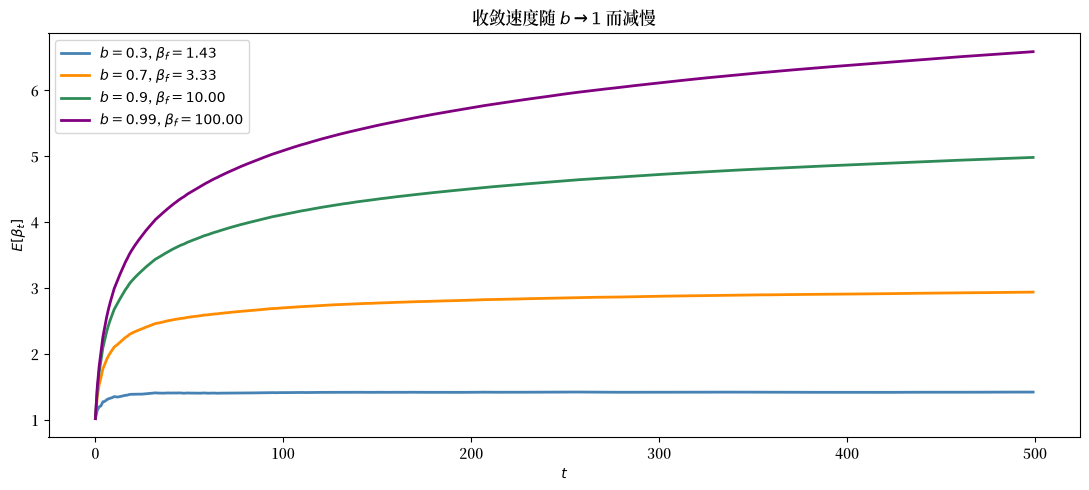

In [10]:
a_ex, T_ex, N_ex = 1.0, 500, 200
b_values = [0.3, 0.7, 0.9, 0.99]
colors_ex = ['steelblue', 'darkorange', 'seagreen', 'purple']

fig, ax = plt.subplots(figsize=(11, 5))
for b_val, col in zip(b_values, colors_ex):
    def T_fn(β, b_val=b_val):
        return a_ex + b_val * β

    paths = simulate_rls_scalar(T_fn, σ_u=1.0, β0=0.0,
                                T_periods=T_ex, N_paths=N_ex, seed=0)
    bf = a_ex / (1 - b_val)
    ax.plot(np.mean(paths, axis=0), color=col, lw=2,
            label=f'$b={b_val}$, $\\beta_f={bf:.2f}$')

ax.set_xlabel('$t$')
ax.set_ylabel('$E[\\beta_t]$')
ax.set_title('收敛速度随 $b \\to 1$ 而减慢')
ax.legend()
plt.tight_layout()
plt.show()

当 $b \to 1$ 时，雅可比矩阵 $\mathcal M = b - 1$ 趋近于零，所以 ODE 返回不动点变得缓慢。

收敛仍然发生，但花费的时间更长。

```{solution-end}
```

```{exercise}
:label: ls_ex2

{prf:ref}`prop-ms-necessity` 陈述了对于内部任何 $\hat\beta \neq \beta_f$ 都有 $\mathbb{P}(\beta_t \to \hat\beta) = 0$。

1. 使用 $a=1$、$b=0.6$ 的 Bray 模型，从 $\beta_0 = 6$（远离 $\beta_f = 2.5$）开始，模拟 100 条长度为 $T = 600$ 的路径，并证明路径仍然收敛到 $\beta_f$。

2. 现在考虑 *不稳定* 情形 $b = 1.5$，从 $\beta_0 = -1.9$（接近 REE $\beta_f = -2$）开始，模拟 50 条长度为 $T = 200$ 的路径，并描述发生了什么。
```

```{solution-start} ls_ex2
:class: dropdown
```

这是一个解答：

*第 1 和第 2 部分。*

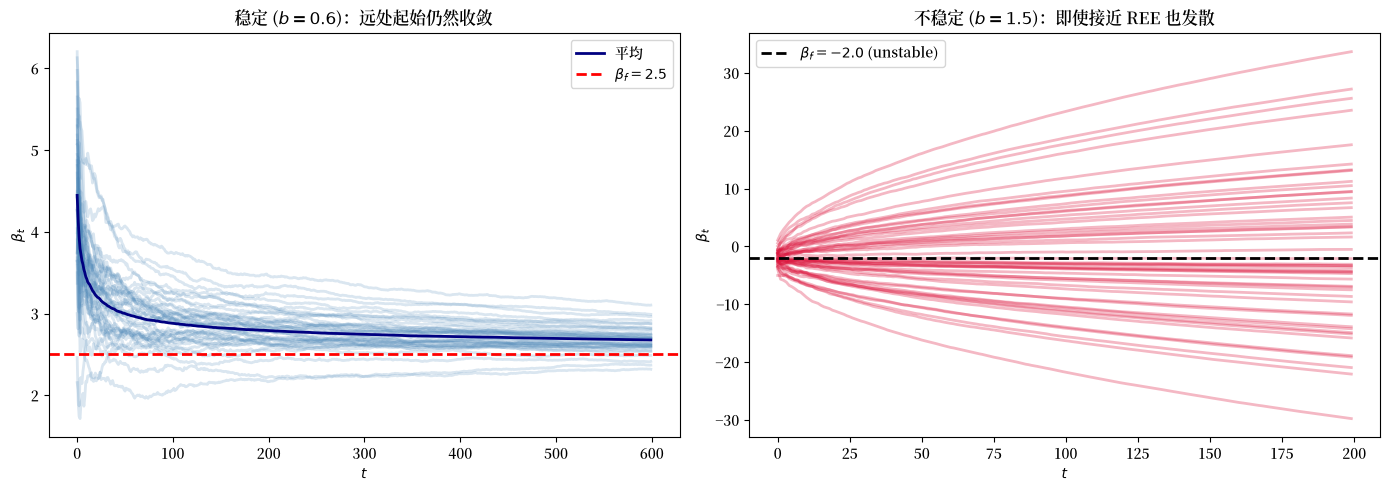

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

def T_st(β):
    return 1.0 + 0.6 * β


paths_far = simulate_rls_scalar(T_st, 1.0, β0=6.0,
                                T_periods=600, N_paths=100, seed=1)
ax = axes[0]
for i in range(40):
    ax.plot(paths_far[i], color='steelblue', alpha=0.2, lw=2)
ax.plot(np.mean(paths_far, axis=0), color='navy', lw=2, label='平均')
ax.axhline(2.5, color='red', ls='--', lw=2, label='$\\beta_f = 2.5$')
ax.set_title('稳定 ($b=0.6$)：远处起始仍然收敛')
ax.set_xlabel('$t$')
ax.set_ylabel('$\\beta_t$')
ax.legend()

def T_un(β):
    return 1.0 + 1.5 * β


β_f_un = 1.0 / (1 - 1.5)
paths_un = simulate_rls_scalar(T_un, 1.0, β0=-1.9,
                               T_periods=200, N_paths=50, seed=2)
ax = axes[1]
for i in range(50):
    ax.plot(paths_un[i], color='crimson', alpha=0.3, lw=2)
ax.axhline(β_f_un, color='black', ls='--', lw=2,
           label=f'$\\beta_f = {β_f_un}$ (unstable)')
ax.set_title('不稳定 ($b=1.5$)：即使接近 REE 也发散')
ax.set_xlabel('$t$')
ax.set_ylabel('$\\beta_t$')
ax.legend()

plt.tight_layout()
plt.show()

从几何上看，斜率 $dT/d\beta - 1 = b - 1 = 0.5$ 在 REE 处为正。

因此 ODE 在两个方向上都将 $\beta$ 推离 $\beta_f$。

```{solution-end}
```

```{exercise}
:label: ls_ex3

现值模型：$\lambda$ 对 E-稳定性的影响

在现值模型 {eq}`eq:pv_model` 中，$T(\beta) = (\lambda\beta + 1)\rho$，雅可比矩阵是 $\mathcal{M} = \lambda\rho - 1$。

1. 对于 $\rho = 0.9$ 和 $\lambda \in \{0.5, 0.8, 0.95, 0.99\}$ 中的每一个，计算 $\beta_f$ 和 $\mathcal{M}$，并判断 REE 是否 E-稳定。

2. 对于 E-稳定的情形，模拟 100 条长度为 $T=400$ 的路径，在日历时间中绘制有代表性的含噪声路径，然后在累积增益时间中绘制极限 ODE 路径。

3. 在 $\lambda = 0.99$ 处，$\mathcal{M} = 0.99\rho - 1 < 0$。

   为这个近边界情形模拟路径，并将收敛速度与 $\lambda = 0.5$ 情形比较，提供一个直观的解释。
```

```{solution-start} ls_ex3
:class: dropdown
```

这是一个解答：

*第 1 部分。*

In [12]:
ρ_ex = 0.9
λ_values = [0.5, 0.8, 0.95, 0.99]

print(f"{'lambda':>8}  {'β_f':>10}  {'M = λ*ρ-1':>15}  {'E-stable':>10}")
print("-" * 50)
for lv in λ_values:
    bf = ρ_ex / (1 - lv * ρ_ex) if abs(lv * ρ_ex) < 1 else float('inf')
    M_jac = lv * ρ_ex - 1
    estab = "YES" if M_jac < 0 else "NO"
    print(f"{lv:>8.2f}  {bf:>10.4f}  {M_jac:>15.4f}  {estab:>10}")

  lambda         β_f        M = λ*ρ-1    E-stable
--------------------------------------------------
    0.50      1.6364          -0.5500         YES
    0.80      3.2143          -0.2800         YES
    0.95      6.2069          -0.1450         YES
    0.99      8.2569          -0.1090         YES


*第 2 和第 3 部分。*

findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


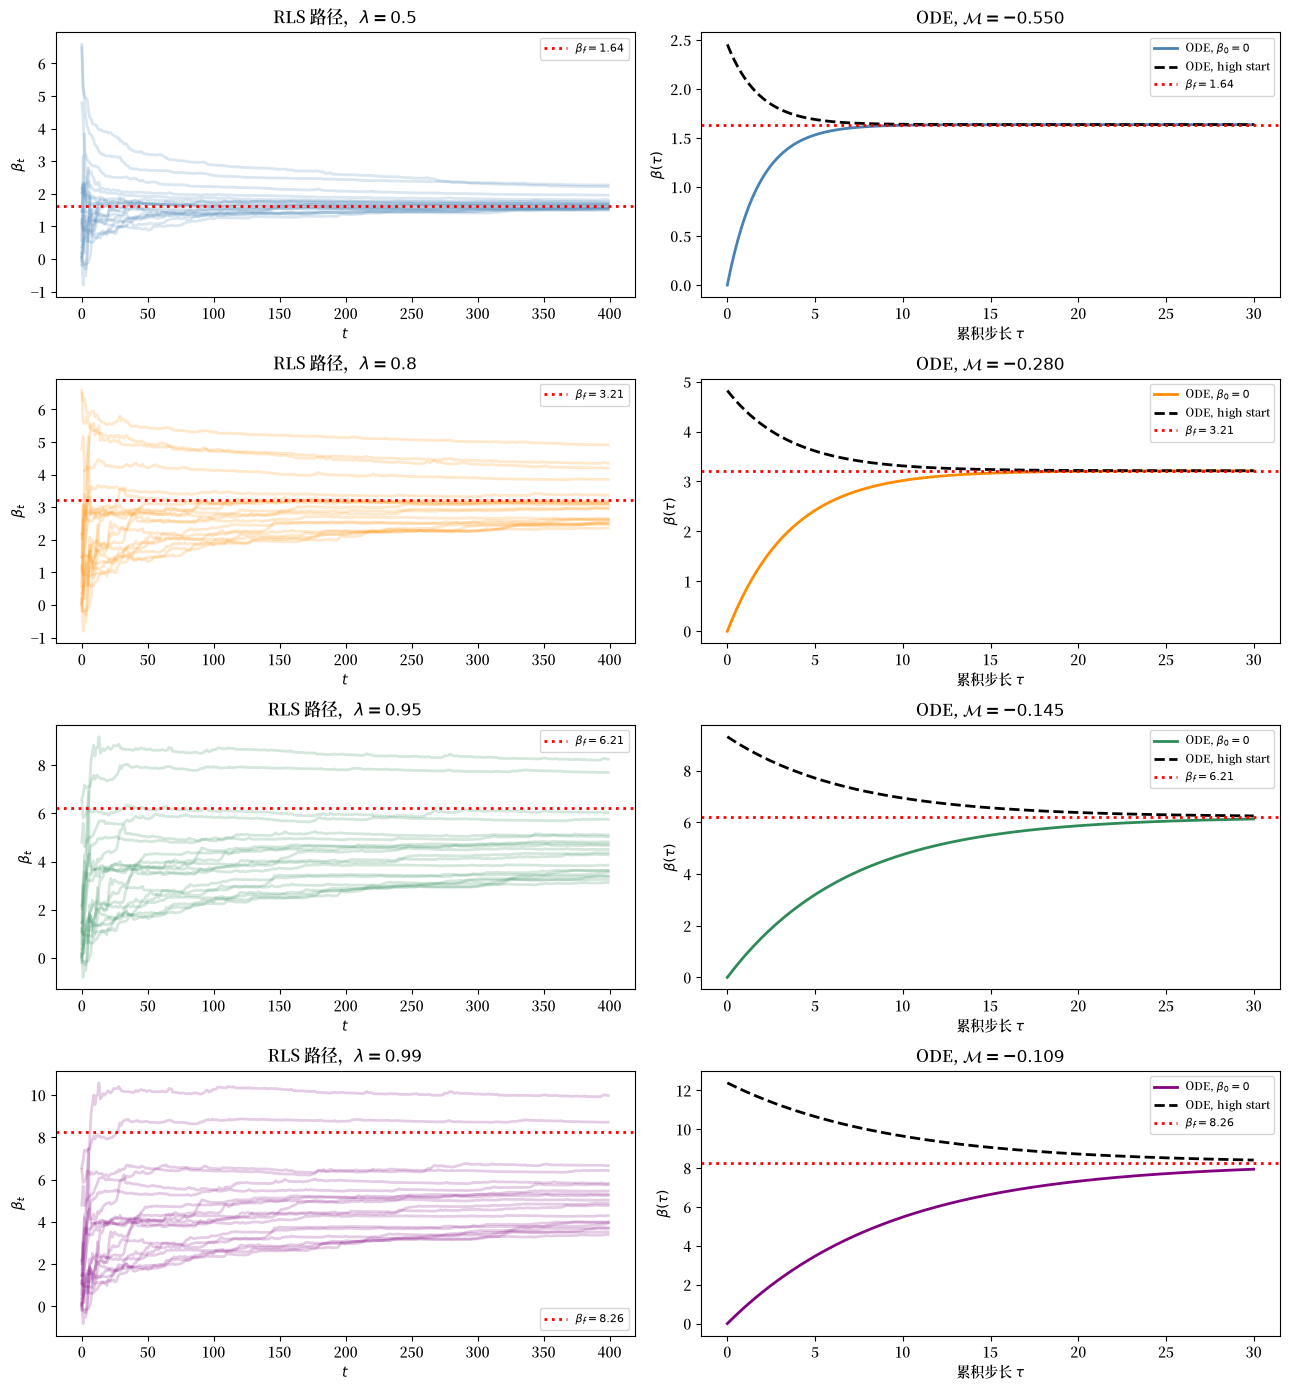

In [13]:
fig, axes = plt.subplots(len(λ_values), 2, figsize=(13, 14))
colors_λ = ['steelblue', 'darkorange', 'seagreen', 'purple']

for row, (lv, col) in enumerate(zip(λ_values, colors_λ)):
    def ode_fn(β, λ_val=lv):
        return (λ_val * β + 1) * ρ_ex - β

    bf = ρ_ex / (1 - lv * ρ_ex)

    paths_λ = simulate_present_value_rls(
        lv, ρ_ex, 1.0, β0=0.0,
        T_periods=400, N_paths=100, seed=3
    )

    ax = axes[row, 0]
    for i in range(20):
        ax.plot(paths_λ[i], color=col, alpha=0.2, lw=2)
    ax.axhline(bf, color='red', ls=':', lw=2,
               label=f'$\\beta_f={bf:.2f}$')
    ax.set_title(f'RLS 路径，$\\lambda={lv}$')
    ax.set_xlabel('$t$')
    ax.set_ylabel('$\\beta_t$')
    ax.legend(fontsize=8)

    τ_grid = np.linspace(0.0, 30.0, 300)
    sol_low = solve_ivp(
        lambda τ, y: [ode_fn(y[0])],
        (0.0, τ_grid[-1]),
        [0.0],
        t_eval=τ_grid,
        max_step=0.05
    ).y[0]
    sol_high = solve_ivp(
        lambda τ, y: [ode_fn(y[0])],
        (0.0, τ_grid[-1]),
        [1.5 * bf],
        t_eval=τ_grid,
        max_step=0.05
    ).y[0]

    ax = axes[row, 1]
    ax.plot(τ_grid, sol_low, color=col, lw=2,
            label='ODE, $\\beta_0=0$')
    ax.plot(τ_grid, sol_high, color='black', ls='--', lw=2,
            label='ODE, high start')
    ax.axhline(bf, color='red', ls=':', lw=2,
               label=f'$\\beta_f={bf:.2f}$')
    M_jac = lv * ρ_ex - 1
    ax.set_title(f'ODE, $\\mathcal{{M}}={M_jac:.3f}$')
    ax.set_xlabel('累积步长 $\\tau$')
    ax.set_ylabel('$\\beta(\\tau)$')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

在每一行中，左面板显示日历时间中的有限样本 RLS 路径，右面板显示累积增益时间中的确定性 ODE 路径。

当 $\lambda=0.99$ 时，$\mathcal M = 0.99\rho-1 \approx -0.109$ 的绝对值很小。

ODE 在 $\beta_f$ 附近几乎是平的，所以恢复力弱，收敛缓慢。

当 $\lambda=0.5$ 时，$\mathcal M=-0.55$，这给出了更强的恢复力和更快的收敛。

```{solution-end}
```